In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path


cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt

# Set global Seaborn style
%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from common.consts import res_colors
from common.utils import collect_df
from common.hlda_utils import load_lambda_grid
from common.plot_utils import scatter_with_labels

data_dir = repo_root / "data"
mfpt_grid_pkl = data_dir / "mfpt_all_thresholds-new-ref.pkl"
mfpt_default_pkl = data_dir / "mfpt-pace=25000-new-ref.pkl"
tm_csv = data_dir / "Tm.csv"
lambda_cache = data_dir / "hlda_lambda_grid.pkl"

with open(mfpt_grid_pkl, "rb") as f:
    mfpt_tables = pickle.load(f)
mfpt_thresholds = sorted(mfpt_tables.keys())

with open(mfpt_default_pkl, "rb") as f:
    mfpt_all = pickle.load(f)

tm = pd.read_csv(tm_csv, index_col="Mutant")
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm["abs_dTm"] = abs(tm["Tm"] - tm.loc["WT", "Tm"])

lambda_grid = load_lambda_grid(cache_path=lambda_cache, base_dir=data_dir / "traj", force=False)
lambda_grid.head()


,Mutant,tF,tU,lambda,n_desc,nF,nU,var_F_diag,var_U_diag,weights,res_weights
0,D2A,0.18,0.30,2689.652245,20,8861,91951,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021822002644914233, 0.034387766655950155, 0...","{'d03': 0.31, 'd04': -0.49, 'd05': 0.41, 'd06'...","[1.51, 0.42, 0.57, 0.84, 1.21, 0.97, 0.46, 0.3..."
1,D2A,0.18,0.35,2725.522197,20,8861,91356,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021914678202689043, 0.034590364267731204, 0...","{'d03': 0.31, 'd04': -0.49, 'd05': 0.41, 'd06'...","[1.51, 0.42, 0.57, 0.84, 1.21, 0.97, 0.46, 0.3..."
2,D2A,0.18,0.41,2910.214620,20,8861,88358,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022499551728532702, 0.03570512795072451, 0....","{'d03': 0.32, 'd04': -0.49, 'd05': 0.41, 'd06'...","[1.52, 0.42, 0.37, 0.86, 1.21, 0.97, 0.47, 0.3..."
3,D2A,0.18,0.46,3384.219373,21,8861,86336,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022895281380262797, 0.03646222800497214, 0....","{'d03': -0.28, 'd04': 0.38, 'd05': -0.41, 'd06...","[1.59, 0.76, 0.76, 0.73, 0.93, 0.98, 0.45, 0.8..."
4,D2A,0.18,0.52,3469.021877,21,8861,84109,"[0.0008478472743267516, 0.0011329781051374278,...","[0.023076225309800618, 0.036911968254067555, 0...","{'d03': 0.28, 'd04': -0.37, 'd05': 0.41, 'd06'...","[1.58, 0.76, 0.76, 0.73, 0.92, 0.98, 0.44, 0.8..."


In [4]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap="rocket_r"):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=6)

    ax.set_xlabel("tU")
    ax.set_ylabel("tF")
    ax.set_title(title, fontsize=9)
    return im


def add_wt_point(ax, lambda_df, tF, tU):
    wt_rows = lambda_df[(lambda_df["Mutant"] == "WT") & np.isclose(lambda_df["tF"], tF) & np.isclose(lambda_df["tU"], tU)]
    if wt_rows.empty:
        return
    x_wt = float(wt_rows["lambda"].iloc[0])
    ax.scatter([x_wt], [0.0], s=90, marker="*", color="red", edgecolor="black", zorder=5)
    y_min, y_max = ax.get_ylim()
    dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
    ax.text(x_wt, dy, "WT", ha="center", va="bottom", fontsize=8, color="red", weight="bold")


def scatter_with_labels_ax(ax, df, x_col, y_col, label_col, title, xlab, ylab, rho, tF, tU, add_wt=True, corr_label="|ρ|"):
    if not df.empty:
        y_min, y_max = df[y_col].min(), df[y_col].max()
        dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
        for _, row in df.iterrows():
            label = str(row[label_col])
            x = row[x_col]
            y = row[y_col]
            color = res_colors.get(int(row.get("residue_idx", np.nan)), "black")
            ax.scatter([x], [y], color=color, alpha=0.85)
            ax.text(x, y + dy, label, fontsize=6.5, ha="center", va="bottom", alpha=0.9)

    if add_wt:
        add_wt_point(ax, lambda_grid, tF, tU)

    ax.set_title(f"{title} {corr_label}={rho:.2f}, n={len(df)}, tF={tF:.2f}, tU={tU:.2f}", fontsize=9)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)


def mfpt_table_to_log_ratio(df_raw):
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()
    df["Mutant"] = df["Mutant"].astype(str).str.strip()
    df["MFPT"] = df["mfpt"] / 1e6
    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["log_mfpt_ratio"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "log_mfpt_ratio"]]


/tmp/ipykernel_1076243/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_1076243/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_1076243/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

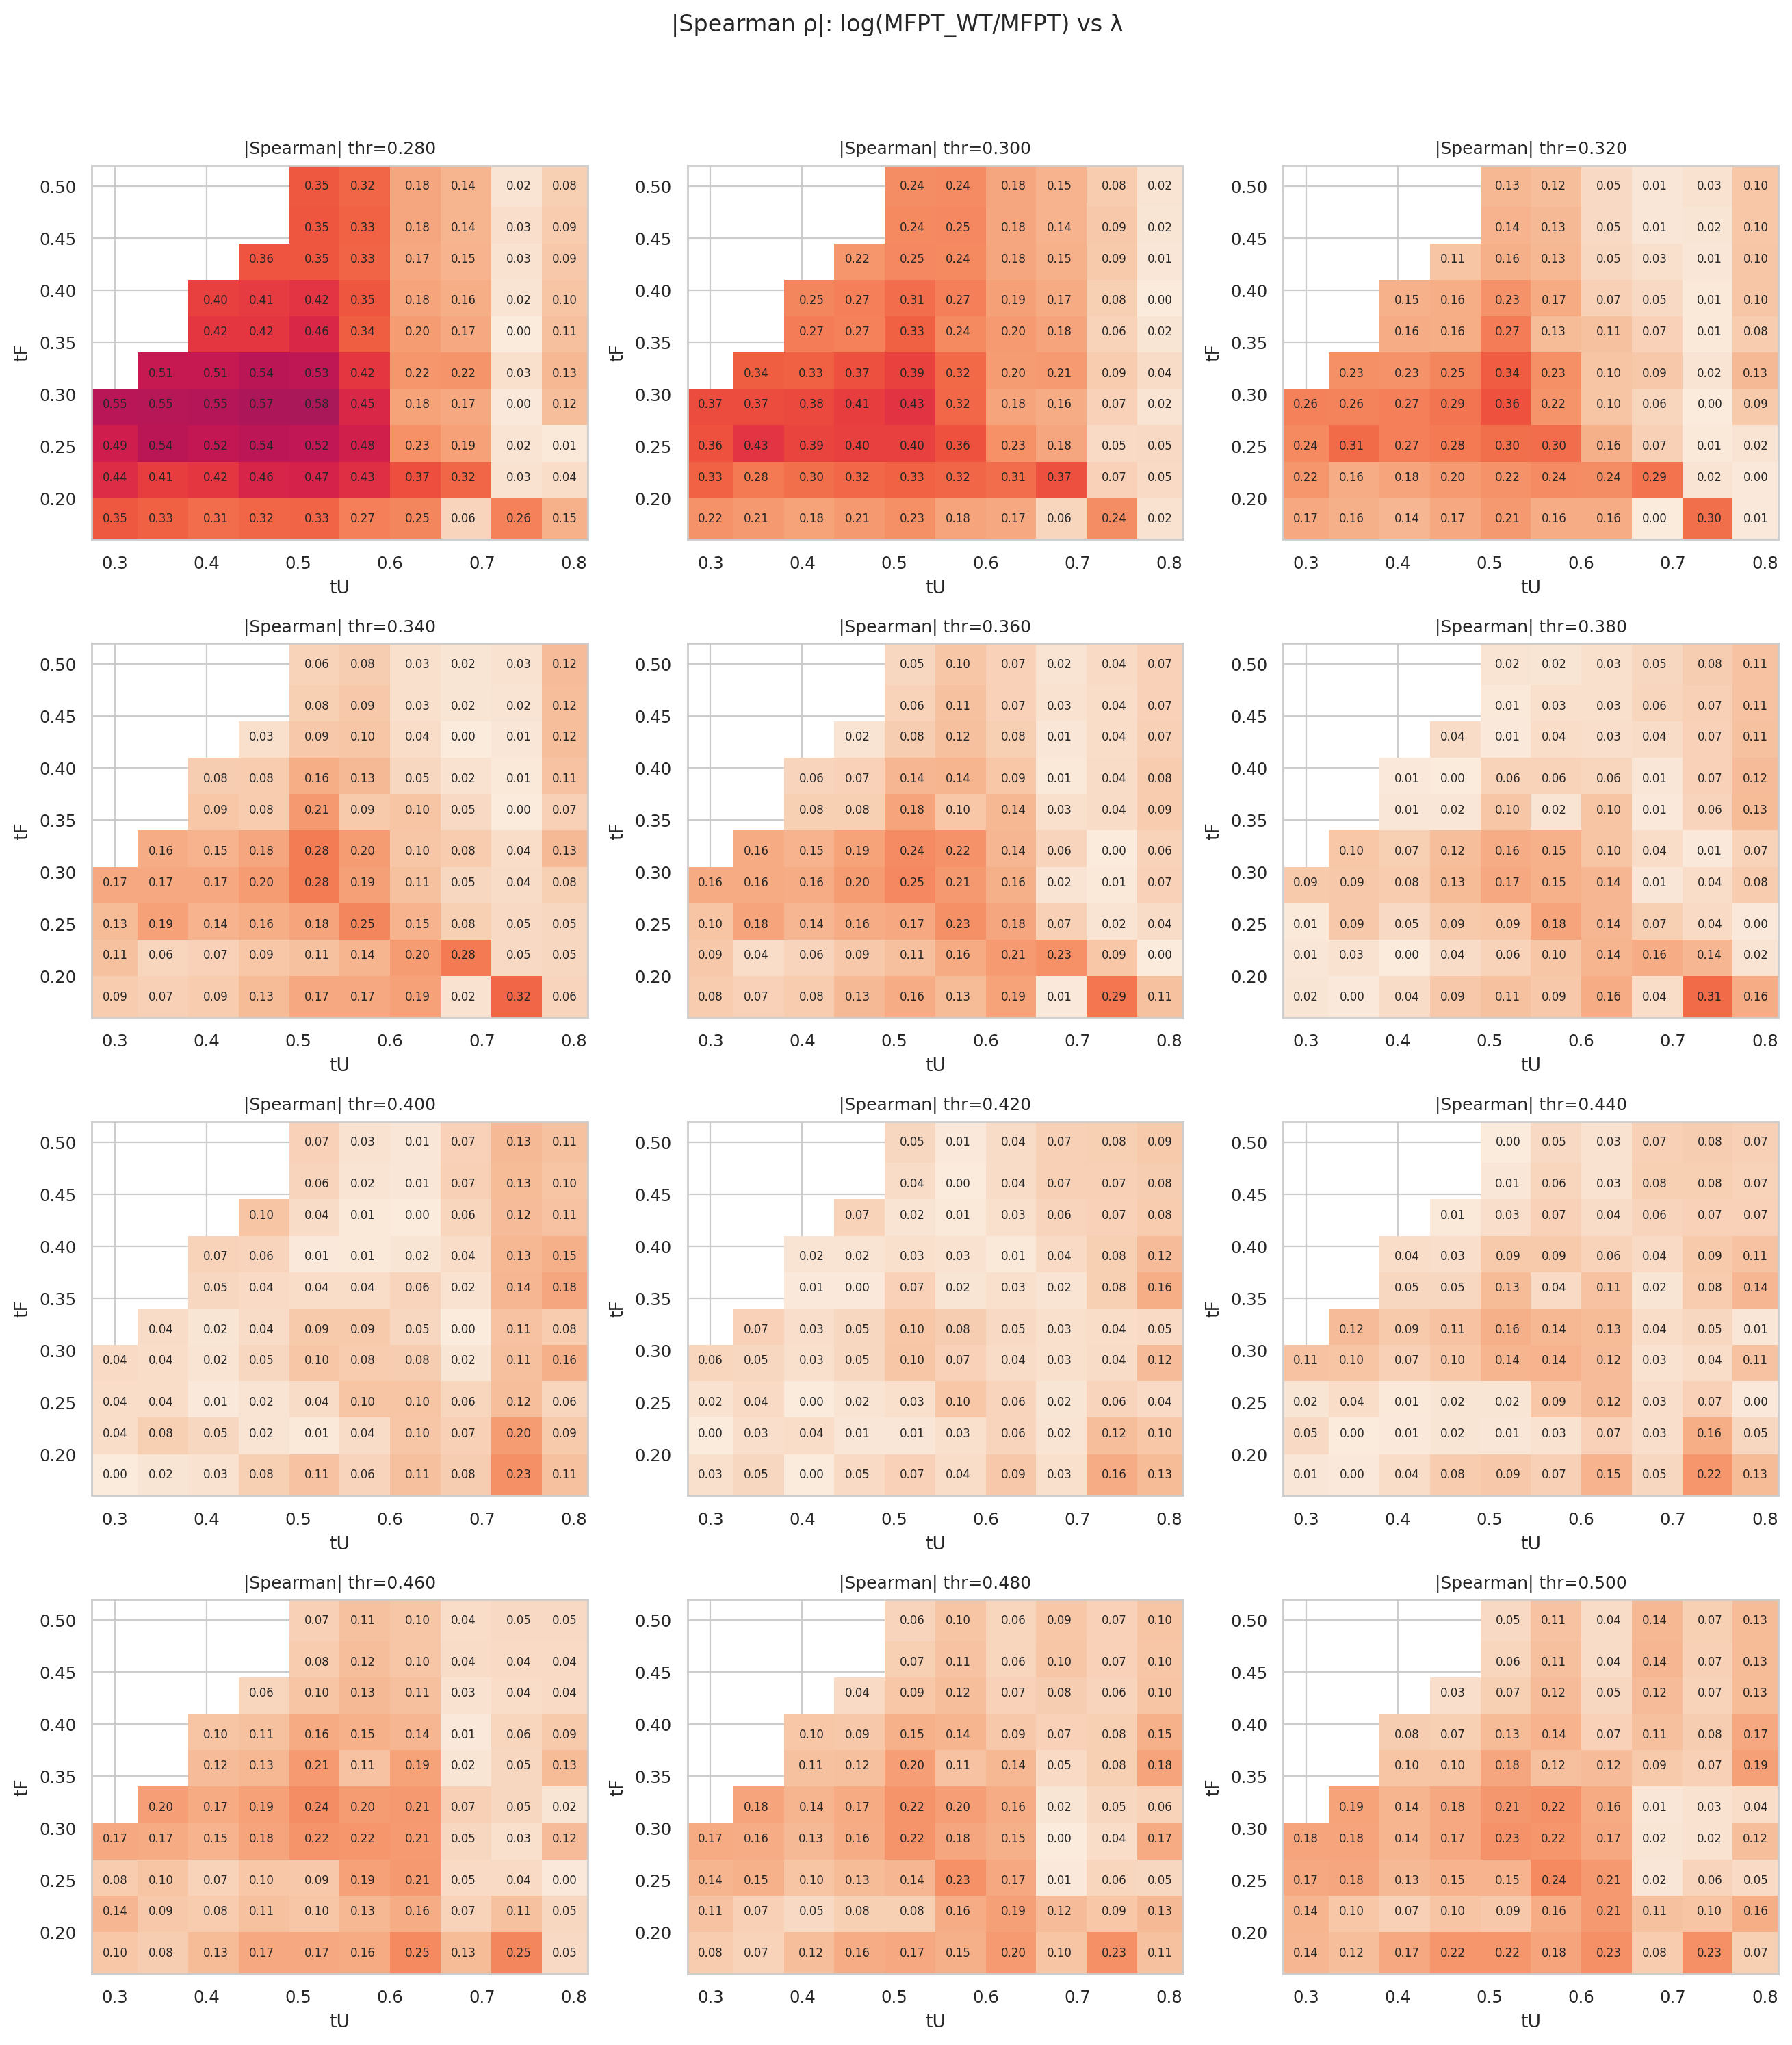

,mfpt_threshold,tF,tU,rho_spear_abs,n
0,0.28,0.29,0.52,0.580917,38
1,0.30,0.29,0.52,0.427071,38
2,0.32,0.29,0.52,0.360980,38
3,0.34,0.18,0.74,0.320495,38
4,0.36,0.18,0.74,0.287231,38
5,0.38,0.18,0.74,0.311960,38
6,0.40,0.18,0.74,0.233614,38
7,0.42,0.18,0.74,0.160959,38
8,0.44,0.18,0.74,0.216763,38
9,0.46,0.18,0.74,0.251997,38


In [5]:
mfpt_results = []

for thr in mfpt_thresholds:
    df_mfpt = mfpt_table_to_log_ratio(mfpt_tables[thr])
    merged = lambda_grid.merge(df_mfpt, on='Mutant', how='left')

    corrs = (
        merged.dropna(subset=['lambda', 'log_mfpt_ratio'])
        .groupby(['tF', 'tU'])
        .apply(lambda g: pd.Series({
            'rho_spear': g['lambda'].corr(g['log_mfpt_ratio'], method='spearman'),
            'rho_spear_abs': abs(g['lambda'].corr(g['log_mfpt_ratio'], method='spearman')),
            'n': len(g),
        }))
        .reset_index()
    )

    best_row = corrs.loc[corrs['rho_spear_abs'].idxmax()] if not corrs.empty else None
    mfpt_results.append({'threshold': thr, 'corrs': corrs, 'best': best_row})

ncols = min(3, len(mfpt_results) if mfpt_results else 1)
nrows = int(np.ceil(len(mfpt_results) / ncols)) if mfpt_results else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, res in zip(axes.ravel(), mfpt_results):
    df = res['corrs'].rename(columns={'rho_spear_abs': 'val'})
    plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['threshold']:.3f}", vmin=0, vmax=1)
for ax in axes.ravel()[len(mfpt_results):]:
    ax.axis('off')
fig.suptitle('|Spearman ρ|: log(MFPT_WT/MFPT) vs λ', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

best_mfpt_df = pd.DataFrame([
    {
        'mfpt_threshold': res['threshold'],
        'tF': float(res['best']['tF']) if res['best'] is not None else np.nan,
        'tU': float(res['best']['tU']) if res['best'] is not None else np.nan,
        'rho_spear_abs': float(res['best']['rho_spear_abs']) if res['best'] is not None else np.nan,
        'n': int(res['best']['n']) if res['best'] is not None else 0,
    }
    for res in mfpt_results
])
best_mfpt_path = data_dir / 'hlda_best_thresholds.csv'
best_mfpt_df.to_csv(best_mfpt_path, index=False)

best_mfpt_df


In [6]:
best_idx = best_mfpt_df['rho_spear_abs'].astype(float).fillna(-np.inf).idxmax()
row_best = best_mfpt_df.loc[best_idx]


tF_best = float(row_best['tF'])
tU_best = float(row_best['tU'])
print(f"Best tf={tF_best}, tU={tU_best}")
mfpt_thr_best = float(row_best['mfpt_threshold'])
rho_s_best = float(row_best['rho_spear_abs']) if not np.isnan(row_best['rho_spear_abs']) else np.nan
print(f"Using tF={tF_best:.2f}, tU={tU_best:.2f} (from MFPT thr={mfpt_thr_best:.3f}), |ρ_s|={rho_s_best:.2f}")

mfpt_threshold_options = [float(x) for x in sorted(mfpt_all['WT'].keys(), key=float)]
mfpt_threshold_for_table = mfpt_thr_best if any(np.isclose(mfpt_thr_best, opt) for opt in mfpt_threshold_options) else mfpt_threshold_options[0]

summary_df = collect_df(
    mfpt_all,
    mfpt_threshold_for_table,
    tF=tF_best,
    tU=tU_best,
    lambda_df=lambda_grid,
    skip_short={},
    quiet=True,
)
wt_mfpt = float(summary_df.loc['WT', 'mfpt'])
summary_df['log_mfpt_ratio'] = np.log(wt_mfpt / summary_df['mfpt'])
summary_path = data_dir / f"hlda_summary_tF={tF_best:.2f}_tU={tU_best:.2f}.csv"
summary_df.to_csv(summary_path)
summary_df[['lambda', 'abs_dvar_F', 'abs_dTm', 'log_mfpt_ratio']].head()



Best tf=0.29, tU=0.52
Using tF=0.29, tU=0.52 (from MFPT thr=0.280), |ρ_s|=0.58


KeyError: 'WT'

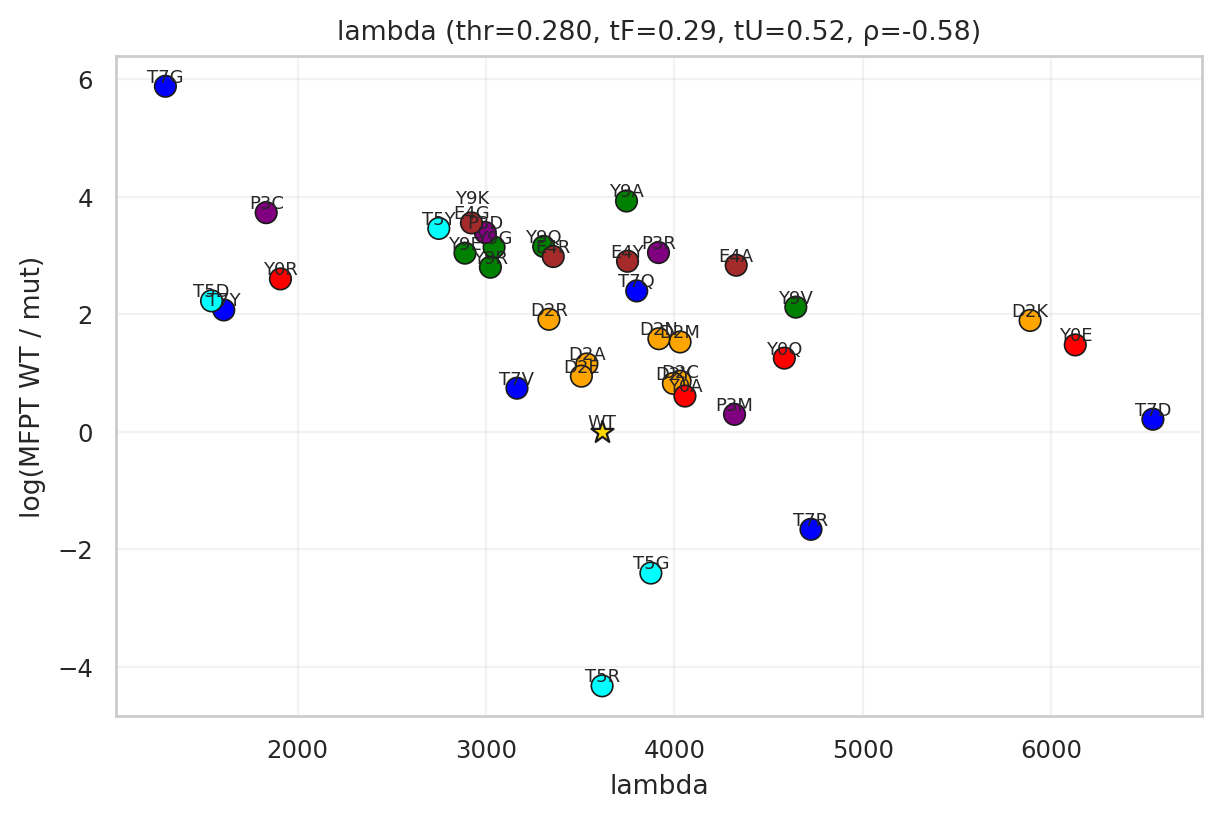

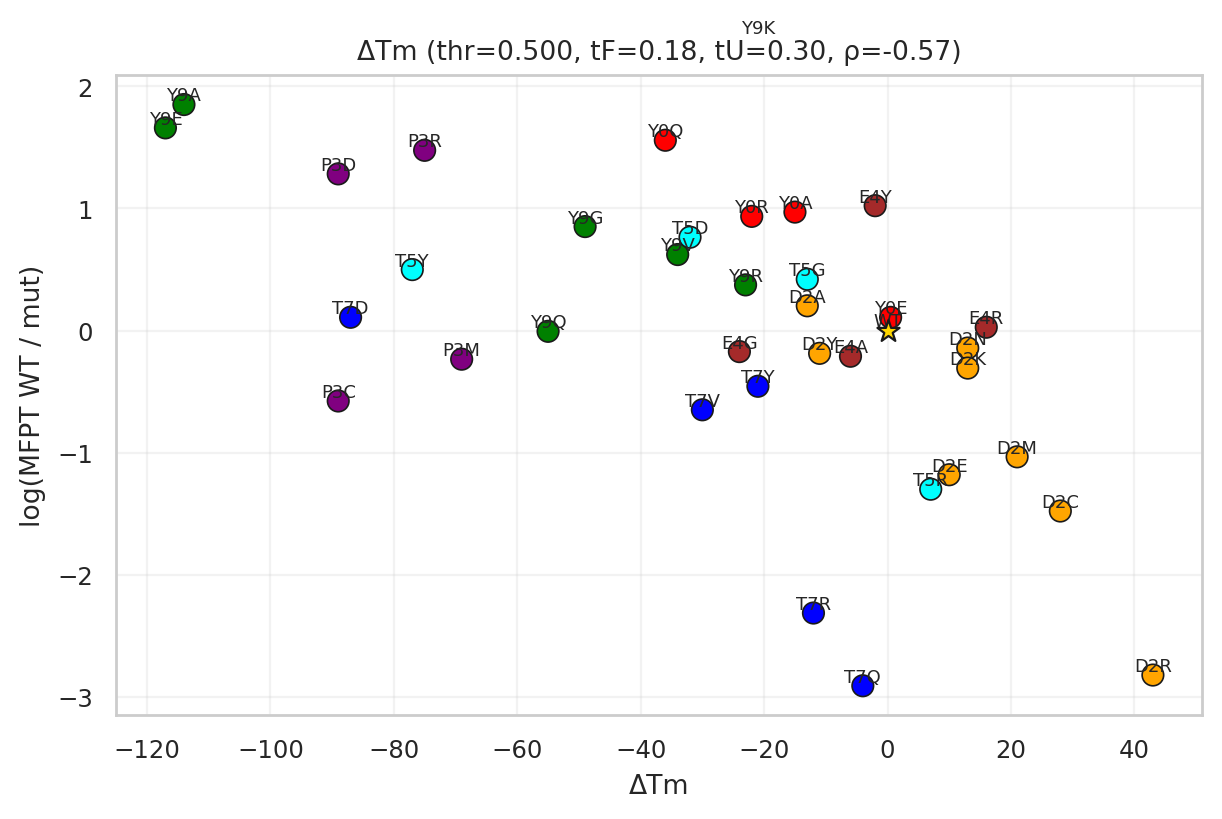

In [ ]:
# Correlations using best thresholds (separate plots)
feature_df_map = {
    'dTm': None,
}

# dTm best
best_dtm = None
pairs = lambda_grid[['tF', 'tU']].drop_duplicates().to_numpy()
for thr in mfpt_thresholds:
    for tF, tU in pairs:
        sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
        df_thr = collect_df(
            mfpt_all,
            mfpt_threshold=float(thr),
            tF=float(tF),
            tU=float(tU),
            lambda_df=sub_lam,
            skip_short={},
            quiet=True,
        )
        wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
        df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
        sub = df_thr.dropna(subset=['dTm', 'log_mfpt_ratio'])
        rho = sub['dTm'].corr(sub['log_mfpt_ratio'], method='spearman')
        val = abs(rho) if pd.notna(rho) else np.nan
        if best_dtm is None or val > best_dtm['rho_abs']:
            best_dtm = {
                'thr': float(thr),
                'tF': float(tF),
                'tU': float(tU),
                'rho_abs': float(val),
            }

_tF = float(best_dtm['tF'])
_tU = float(best_dtm['tU'])
_thr = float(best_dtm['thr'])
_sub_lam = lambda_grid[(lambda_grid['tF'] == _tF) & (lambda_grid['tU'] == _tU)]
_df = collect_df(
    mfpt_all,
    mfpt_threshold=_thr,
    tF=_tF,
    tU=_tU,
    lambda_df=_sub_lam,
    skip_short={},
    quiet=True,
)
_wt_mfpt = float(_df.loc['WT', 'mfpt'])
_df['log_mfpt_ratio'] = np.log(_wt_mfpt / _df['mfpt'])
feature_df_map['dTm'] = _df

# Lambda (MFPT-best) plot
sub = summary_df.dropna(subset=['lambda', 'log_mfpt_ratio']).copy()
fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
sns.scatterplot(data=sub, x='lambda', y='log_mfpt_ratio', hue='residue_idx', palette=palette, s=60, edgecolor='k', linewidth=0.6, ax=ax, legend=False)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['lambda'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.scatter(wt_x, wt_y, s=70, marker='*', edgecolor='k', facecolor='gold', zorder=4)
for name, row in sub.iterrows():
    ax.text(row['lambda'], row['log_mfpt_ratio'], name, fontsize=6.5, ha='center', va='bottom')
rho = sub['lambda'].corr(sub['log_mfpt_ratio'], method='spearman')
ax.set_title(f"lambda (thr={mfpt_thr_best:.3f}, tF={tF_best:.2f}, tU={tU_best:.2f}, ρ={rho:.2f})")
ax.set_xlabel('lambda')
ax.set_ylabel('log(MFPT WT / mut)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()



# dTm plot
sub = feature_df_map['dTm'].dropna(subset=['dTm', 'log_mfpt_ratio']).copy()
fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
sns.scatterplot(data=sub, x='dTm', y='log_mfpt_ratio', hue='residue_idx', palette=palette, s=60, edgecolor='k', linewidth=0.6, ax=ax, legend=False)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['dTm'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.scatter(wt_x, wt_y, s=70, marker='*', edgecolor='k', facecolor='gold', zorder=4)
for name, row in sub.iterrows():
    ax.text(row['dTm'], row['log_mfpt_ratio'], name, fontsize=6.5, ha='center', va='bottom')
rho = sub['dTm'].corr(sub['log_mfpt_ratio'], method='spearman')
ax.set_title(f"ΔTm (thr={best_dtm['thr']:.3f}, tF={best_dtm['tF']:.2f}, tU={best_dtm['tU']:.2f}, ρ={rho:.2f})")
ax.set_xlabel('ΔTm')
ax.set_ylabel('log(MFPT WT / mut)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


/home/alexz/Repos/protein-toolkit/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Best combo: alpha=-0.85, beta=0.53, ρ=0.61


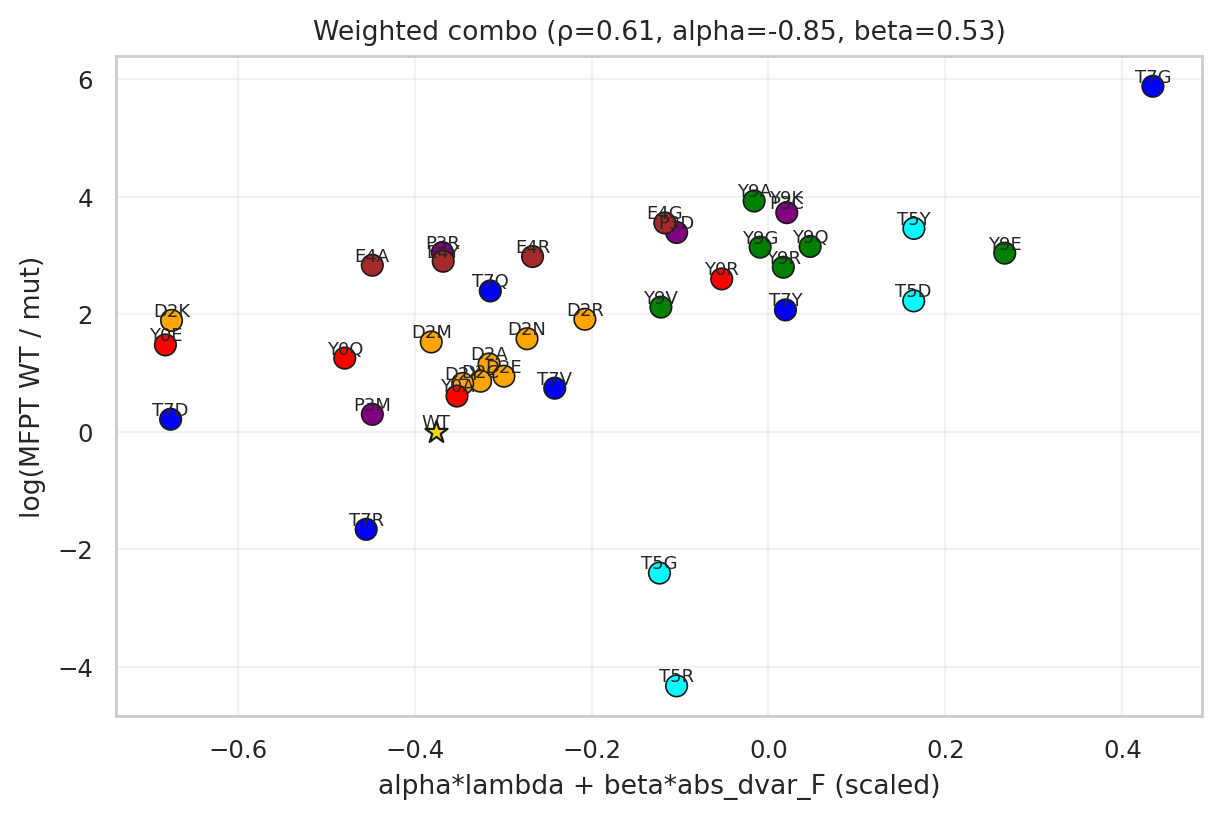

In [ ]:
# Combine lambda + abs_dvar_F with weighted sum (optimize alpha, beta)
sub = summary_df.dropna(subset=['lambda', 'abs_dvar_F', 'log_mfpt_ratio']).copy()

lmin, lmax = sub['lambda'].min(), sub['lambda'].max()
amin, amax = sub['abs_dvar_F'].min(), sub['abs_dvar_F'].max()
sub['lambda_z'] = (sub['lambda'] - lmin) / (lmax - lmin) if lmax > lmin else 0.0
sub['abs_dvar_F_z'] = (sub['abs_dvar_F'] - amin) / (amax - amin) if amax > amin else 0.0

best = None
for alpha in np.linspace(-1.0, 1.0, 81):
    for beta in np.linspace(-1.0, 1.0, 81):
        comb = alpha * sub['lambda_z'] + beta * sub['abs_dvar_F_z']
        rho = comb.corr(sub['log_mfpt_ratio'], method='spearman')
        val = abs(rho) if pd.notna(rho) else np.nan
        if pd.isna(val):
            continue
        if best is None or val > best['rho_abs']:
            best = {'alpha': float(alpha), 'beta': float(beta), 'rho_abs': float(val), 'rho': float(rho)}

print(f"Best combo: alpha={best['alpha']:.2f}, beta={best['beta']:.2f}, ρ={best['rho']:.2f}")
sub['combo'] = best['alpha'] * sub['lambda_z'] + best['beta'] * sub['abs_dvar_F_z']

fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
sns.scatterplot(data=sub, x='combo', y='log_mfpt_ratio', hue='residue_idx', palette=palette, s=60, edgecolor='k', linewidth=0.6, ax=ax, legend=False)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['combo'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.scatter(wt_x, wt_y, s=70, marker='*', edgecolor='k', facecolor='gold', zorder=4)
for name, row in sub.iterrows():
    ax.text(row['combo'], row['log_mfpt_ratio'], name, fontsize=6.5, ha='center', va='bottom')
ax.set_title(f"Weighted combo (ρ={best['rho']:.2f}, alpha={best['alpha']:.2f}, beta={best['beta']:.2f})")
ax.set_xlabel('alpha*lambda + beta*abs_dvar_F (scaled)')
ax.set_ylabel('log(MFPT WT / mut)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


[1.85, 0.48, 0.39, 0.65, 1.25, 1.15, 0.58, 0.4, 0.7, 1.53]


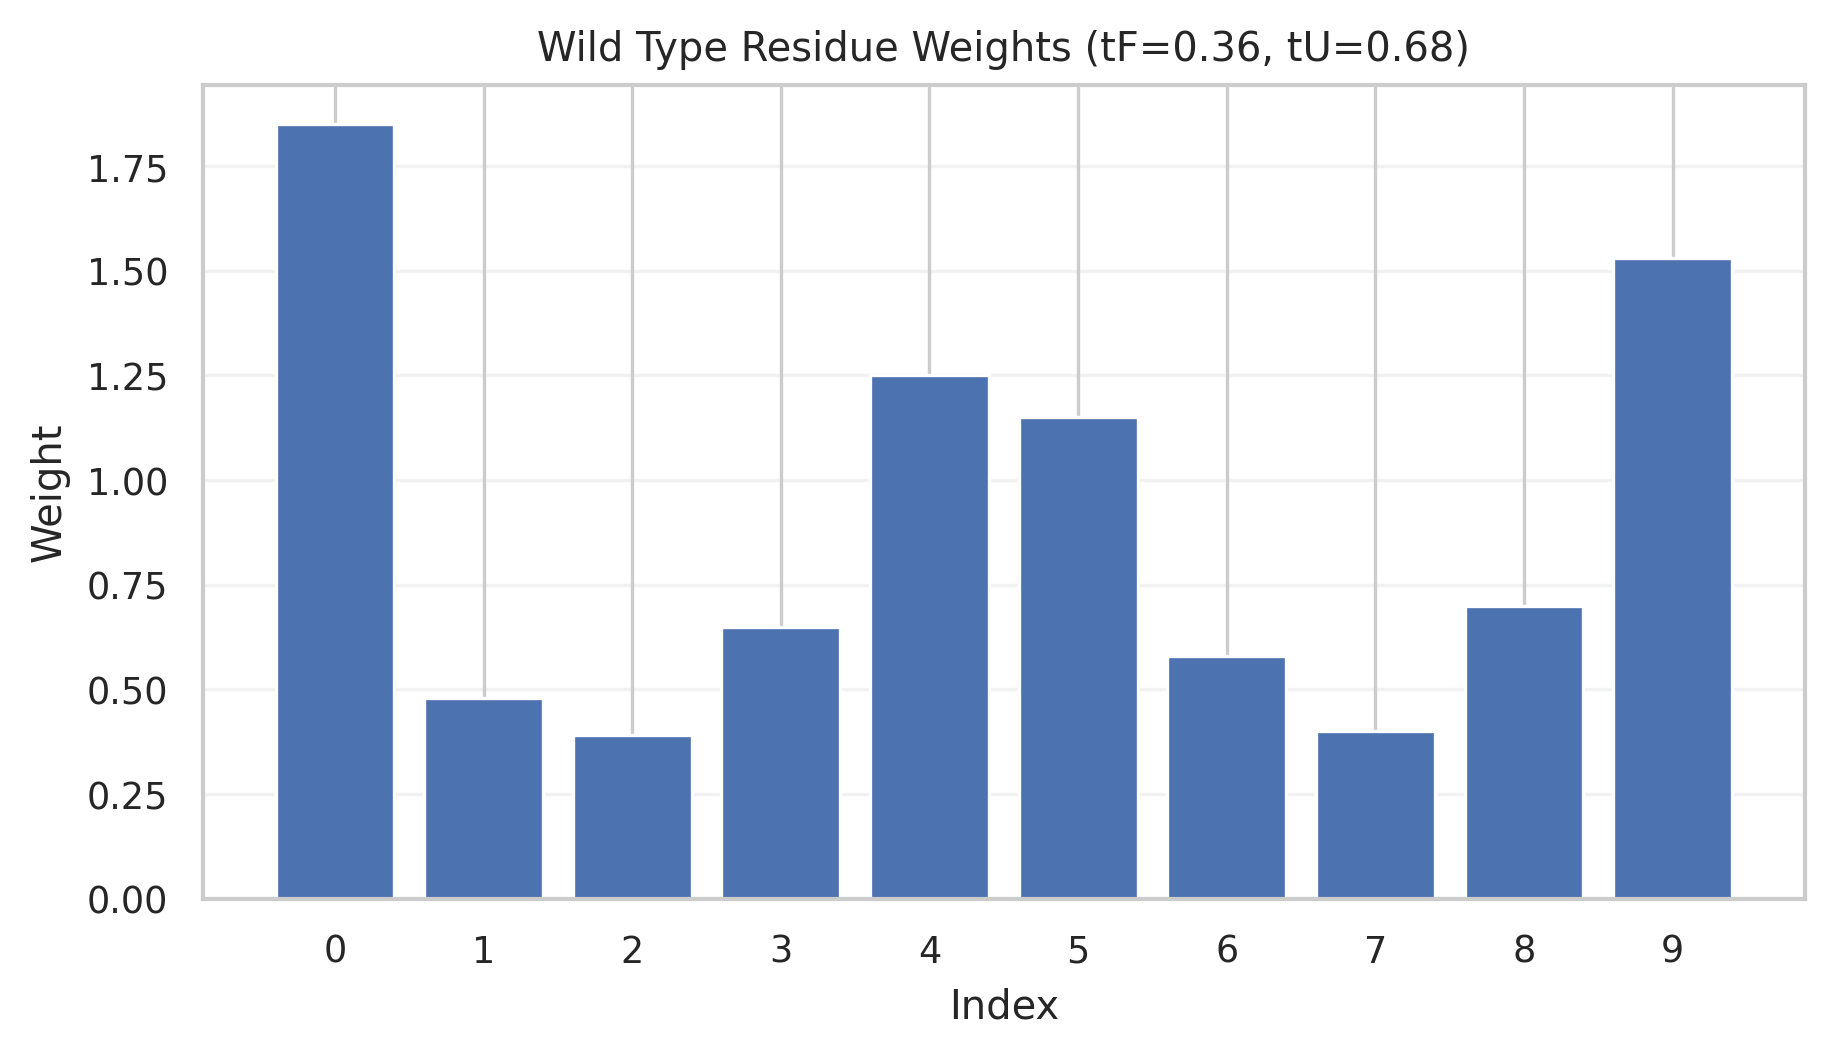

In [ ]:
tF = 0.36
tU = 0.68

wt_row = lambda_grid[(lambda_grid['Mutant'] == 'WT') & (lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
res_weights = wt_row.iloc[0]['res_weights']

print(res_weights)
fig, ax = plt.subplots(figsize=(6.2, 3.6), dpi=150)
ax.bar(list(range(len(res_weights))), res_weights, color='#4C72B0')
ax.set_xlabel('Index')
ax.set_ylabel('Weight')
ax.set_title(f'Wild Type Residue Weights (tF={tF:.2f}, tU={tU:.2f})')
ax.set_xticks(list(range(0, 10)))
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
